## Analysis of user-prepared vs core-prepared libraries

In [13]:
project_data <- read.csv("./data/project_withAssignmentColumn_deID.csv")

In [14]:
head(project_data)

,row,project_uid,primary_investigator_uid,creation_date,assigned_to
,<int>,<int>,<int>,<chr>,<chr>
1,1,1,1,4/20/2011,NULL
2,2,2,2,4/20/2011,NULL
3,3,3,3,4/20/2011,NULL
4,4,4,4,4/21/2011,NULL
5,5,5,4,4/21/2011,NULL
6,6,6,4,4/21/2011,NULL


In [15]:
table(project_data[, c("assigned_to")])


               core       N/A      NULL user prep 
      667       916         3       699       381 

In [16]:
substrRight <- function(x, n){
  substr(x, nchar(x)-n+1, nchar(x))
}

In [17]:
project_data$year <- substrRight(project_data$creation_date, n = 4)
head(project_data$year)

[1] "2011" "2011" "2011" "2011" "2011" "2011"

In [18]:
table(project_data[, c("assigned_to", "year")])

           year
assigned_to 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2999
               0    0   27   12   18    9   18   46  229  240   67    0    1
  core         0    4   74  111  118  122  140  253   81   12    0    0    1
  N/A          0    0    3    0    0    0    0    0    0    0    0    0    0
  NULL        74  167  103    7    8    1    8    9   39   73  197   13    0
  user prep    0    0   14   26   96   76   66   42   45   13    3    0    0

### Given incomplete records, how many are 'user prep' out of all experiments with values attached?

In [19]:
dim(project_data)
data.subset <- project_data[project_data$assigned_to!="NULL", ]
dim(data.subset)
data.subset <- data.subset[data.subset$assigned_to!="", ]
dim(data.subset)

[1] 2666    6

[1] 1967    6

[1] 1300    6

### Analyze data with known assigned_to status only

In [20]:
data.subset <- project_data[project_data$assigned_to!="NULL", ]
data.subset <- data.subset[data.subset$assigned_to!="", ]
data.subset <- data.subset[data.subset$assigned_to!="N/A", ]

In [21]:
table(data.subset[, c("assigned_to", "year")])

           year
assigned_to 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2999
  core         4   74  111  118  122  140  253   81   12    0    1
  user prep    0   14   26   96   76   66   42   45   13    3    0

## Plot user vs core prepped libraries

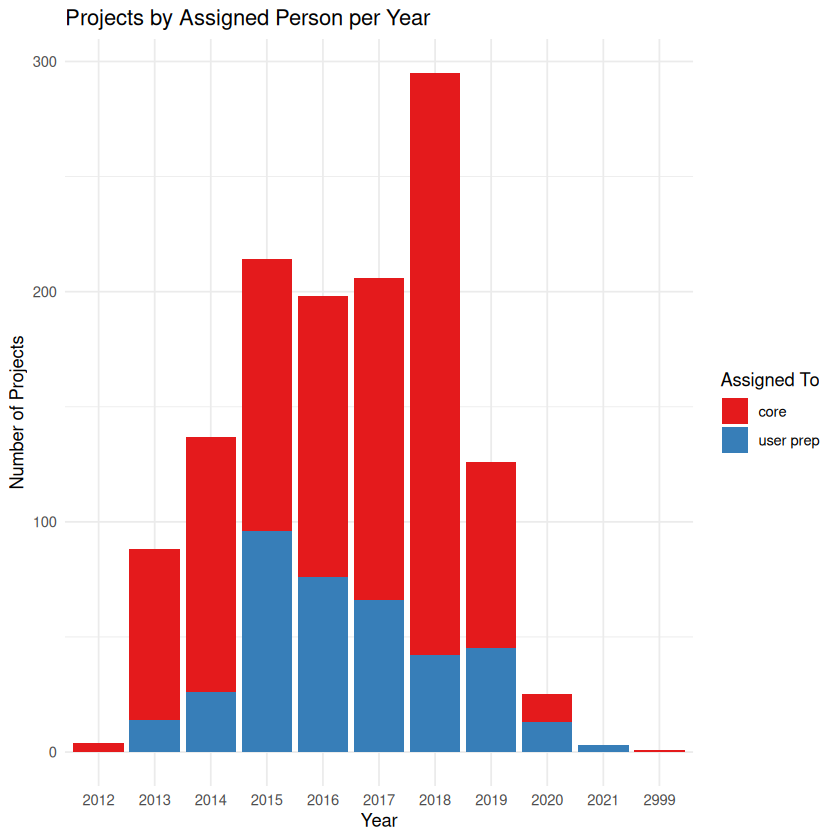

In [22]:
library(ggplot2)
library(dplyr)
library(forcats)

# Reorder by total count across all years
top5_levels <- data.subset %>%
  count(assigned_to) %>%
  top_n(5, n) %>%
  pull(assigned_to)

# Add a reordered factor with top 5 kept and rest lumped as "Other"
data.subset <- data.subset %>%
  mutate(
    assigned_to_grouped = fct_lump(fct_infreq(assigned_to), n = 5),
    assigned_to_grouped = fct_reorder(assigned_to_grouped, assigned_to_grouped, .fun = function(x) sum(x == x), .desc = TRUE)
  )

# Plot
ggplot(data.subset, aes(x = year, fill = assigned_to_grouped)) +
  geom_bar(position = "stack") +
  scale_fill_brewer(palette = "Set1", name = "Assigned To") +
  labs(x = "Year", y = "Number of Projects", title = "Projects by Assigned Person per Year") +
  theme_minimal()


### Filter out years with zero to no data

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


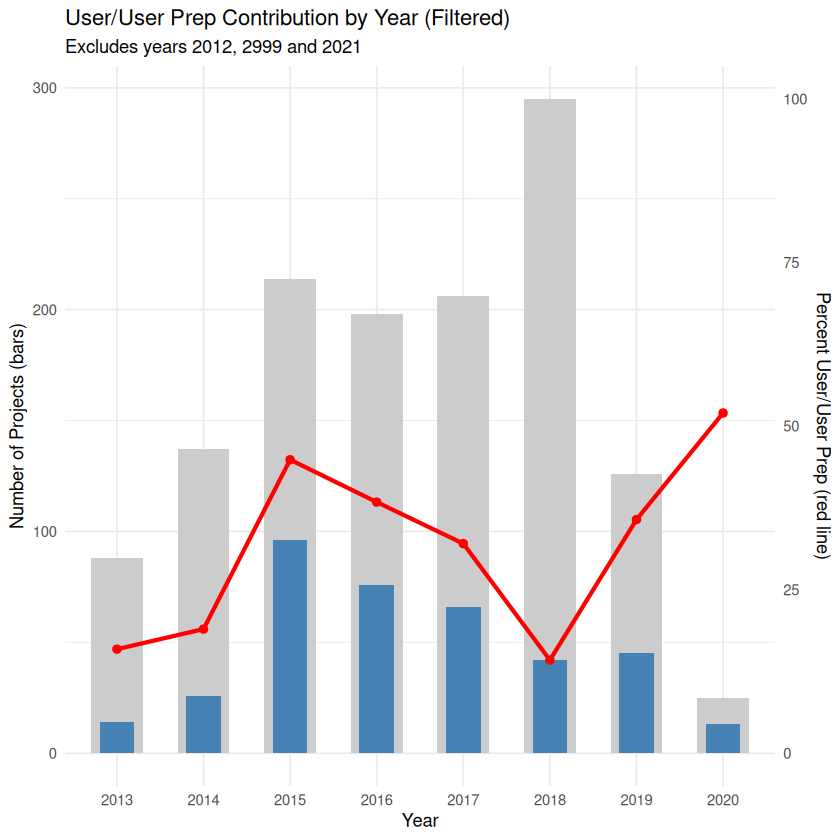

In [24]:
library(ggplot2)
library(dplyr)

# Filter out problematic years
filtered_data <- data.subset %>%
  filter(!year %in% c(2999, 2021, 2012))

# Create summary table
summary_df <- filtered_data %>%
  group_by(year) %>%
  summarise(
    total = n(),
    user_related = sum(assigned_to %in% c("user", "user prep"))
  ) %>%
  mutate(
    percent = 100 * user_related / total
  )

# Plot with dual axes
ggplot(summary_df, aes(x = factor(year))) +
  geom_col(aes(y = total), fill = "grey80", width = 0.6) +  # Total as background bars
  geom_col(aes(y = user_related), fill = "steelblue", width = 0.4) +  # 'user' + 'user prep' as overlay
  geom_line(aes(y = percent * max(total) / 100), group = 1, color = "red", size = 1.2) +
  geom_point(aes(y = percent * max(total) / 100), color = "red", size = 2) +
  scale_y_continuous(
    name = "Number of Projects (bars)",
    sec.axis = sec_axis(~ . * 100 / max(summary_df$total), name = "Percent User/User Prep (red line)")
  ) +
  labs(
    x = "Year",
    title = "User/User Prep Contribution by Year (Filtered)",
    subtitle = "Excludes years 2012, 2999 and 2021"
  ) +
  theme_minimal()


In [25]:
pdf("GenomicsCore_userVsCorePreps_060625.pdf", width = 6, height = 6)
p1 <- ggplot(summary_df, aes(x = factor(year))) +
  geom_col(aes(y = total), fill = "grey80", width = 0.6) +  # Total as background bars
  geom_col(aes(y = user_related), fill = "steelblue", width = 0.4) +  # 'user' + 'user prep' as overlay
  geom_line(aes(y = percent * max(total) / 100), group = 1, color = "red", size = 1.2) +
  geom_point(aes(y = percent * max(total) / 100), color = "red", size = 2) +
  scale_y_continuous(
    name = "Number of Projects (bars)",
    sec.axis = sec_axis(~ . * 100 / max(summary_df$total), name = "Percent User/User Prep (red line)")
  ) +
  labs(
    x = "Year",
    title = "User/User Prep Contribution by Year (Filtered)",
    subtitle = "Excludes years 2012, 2999 and 2021"
  ) +
  theme_minimal()
p1
dev.off()

pdf 
  2